In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

In [3]:
def get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED):
    if WITH_MET and RAW_OR_NORMALIZED == "raw":
        WITH_MET = "_with_raw_met"
    elif WITH_MET and RAW_OR_NORMALIZED == "normalized":
        WITH_MET = "_with_normalized_met"
    else:
        WITH_MET = ""

    if PRODUCT == "gridded":
        PRODUCT_NAME = "_gridded"
        FOLDER_NAME = "gridded_events"
    elif PRODUCT == "events":
        PRODUCT_NAME = ""
        FOLDER_NAME = "events"
    else:
        PRODUCT_NAME = ""
    if SRC in ['asfs', 'sos']:
        SITE = 'kettle_ponds'
    elif SRC in ['bb', 'sail']:
        SITE = 'gothic'
    else:
        SITE = input("Enter site name (gothic or kettle_ponds): ")
    return DATA_DIR / SITE / f"{FOLDER_NAME}{WITH_MET}" / f"{SITE}{PRODUCT_NAME}_precipitation_event_comparisons_{SRC}{WITH_MET}.nc"

In [4]:
DATA_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis'
# Define your root and sites
DATA_DIR = Path(DATA_DIR)
STORAGE_DIR = '/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/events'
SRC = "sail" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or events
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")

ds = xr.open_dataset(file_dest)

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/gothic/events_with_raw_met/gothic_precipitation_event_comparisons_sail_with_raw_met.nc


# Event size rank correlation
To do: just add all sites and color the two differently

In [69]:
vars_to_remove =["billy_barr_precip", "sail_pwd_rain", "sail_squire_rain", "sail_tbg_corr"]
rank_correlations = {}
for instrument in ds.test_instrument.values:
    if instrument in vars_to_remove:
        continue
    sub_df = ds.sel(benchmark='billy_barr_precip', test_instrument=instrument, event_id=slice(1,50))[['benchmark_total','abs_diff']].to_dataframe()
    sub_df = sub_df.reset_index()
    sub_df = sub_df.sort_values('benchmark_total', ascending=False)
    sub_df = sub_df.reset_index(drop=True)
    sub_df.index.name = 'event_ppt_rank'
    sub_df = sub_df.reset_index()
    sub_df['event_ppt_rank'] = sub_df['event_ppt_rank'] + 1  # make rank start at 1
    sub_df = sub_df.dropna()
    corr, p_value = stats.spearmanr(sub_df['event_ppt_rank'], sub_df['event_id'])
    rank_correlations[instrument] = (corr, p_value)

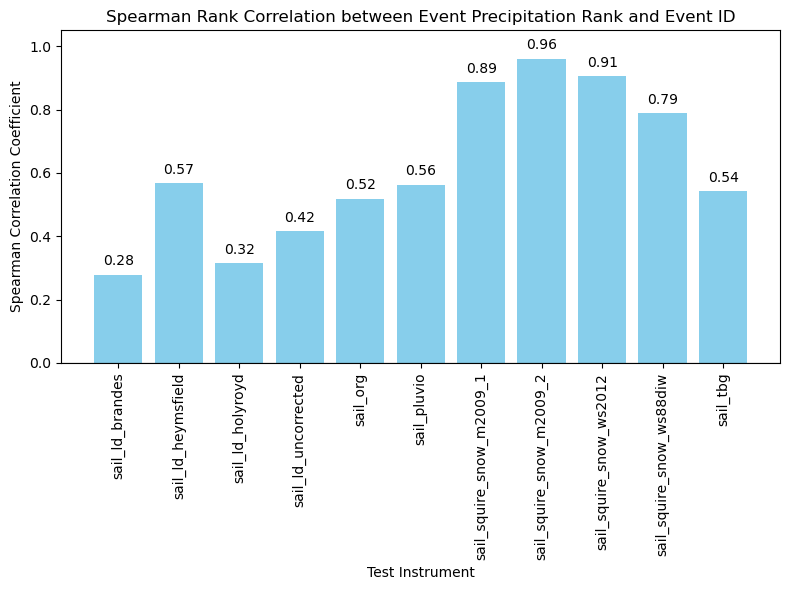

In [70]:
# build a dataframe from the results
rank_corr_df = pd.DataFrame.from_dict(rank_correlations, orient='index', columns=['spearman_correlation', 'p_value'])

plt.figure(figsize=(8,6))
bars = plt.bar(rank_corr_df.index, rank_corr_df['spearman_correlation'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Spearman Rank Correlation between Event Precipitation Rank and Event ID')
plt.xlabel('Test Instrument')
plt.ylabel('Spearman Correlation Coefficient')
plt.ylim(0, 1.05)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Normalized Event size rank correlation
To do: just add all sites and color the two differently

In [ ]:
# lets compare the ranks of the normalized bias to the event ids
rank_correlations = {}
for instrument in ds.test_instrument.values:
    if instrument in vars_to_remove:
        continue
    sub_df = ds.sel(benchmark='billy_barr_precip', test_instrument=instrument)[['benchmark_total','abs_diff']].to_dataframe()
    sub_df = sub_df.reset_index()
    sub_df = sub_df.sort_values('benchmark_total', ascending=False)
    sub_df = sub_df.reset_index(drop=True)
    sub_df.index.name = 'event_ppt_rank'
    sub_df = sub_df.reset_index()
    sub_df['event_ppt_rank'] = sub_df['event_ppt_rank'] + 1  # make rank start at 1
    sub_df = sub_df.dropna()
    normalized_bias = sub_df['abs_diff'] / sub_df['benchmark_total']
    min_event_size = 2.5  # in mm
    normalized_bias = normalized_bias.where(sub_df['benchmark_total'] >= min_event_size, 0)
    normalized_bias = normalized_bias.where(np.isfinite(normalized_bias), np.nan)
    normalized_bias = normalized_bias.sort_values(ascending=False)
    corr, p_value = stats.spearmanr(normalized_bias.index, sub_df['event_id'])
    rank_correlations[instrument] = (corr, p_value)
rank_corr_df = pd.DataFrame.from_dict(rank_correlations, orient='index', columns=['spearman_correlation', 'p_value'])

,spearman_correlation,p_value
sail_ld_brandes,0.388577,3.205019e-06
sail_ld_heymsfield,0.416237,5.672463e-07
sail_ld_holyroyd,0.364477,1.287134e-05
sail_ld_uncorrected,0.396737,1.589747e-06
sail_org,0.459674,2.307759e-08
sail_pluvio,0.302511,6.718890e-04
sail_squire_snow_m2009_1,0.637670,2.817177e-12
sail_squire_snow_m2009_2,0.590435,3.767418e-10
sail_squire_snow_ws2012,0.562100,2.535392e-09
sail_squire_snow_ws88diw,0.394891,7.489542e-05


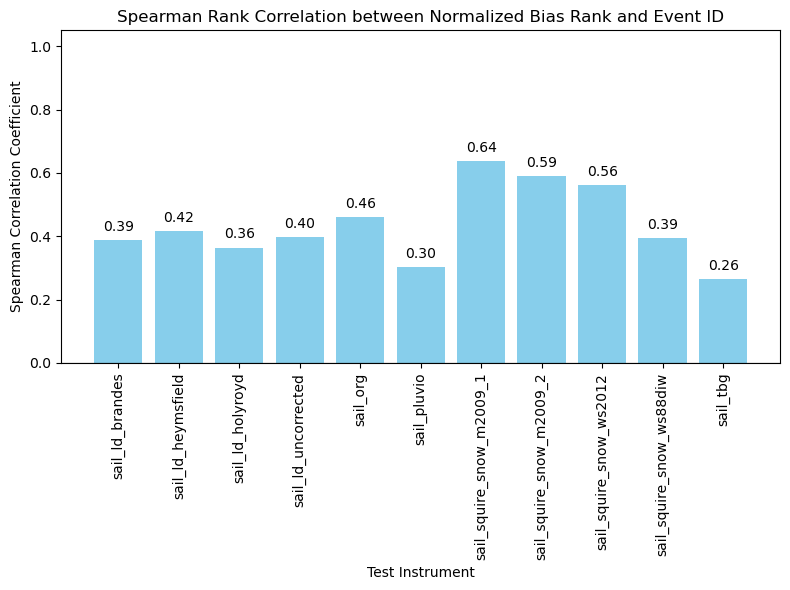

In [86]:
rank_corr_df = pd.DataFrame.from_dict(rank_correlations, orient='index', columns=['spearman_correlation', 'p_value'])
plt.figure(figsize=(8,6))
bars = plt.bar(rank_corr_df.index, rank_corr_df['spearman_correlation'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Spearman Rank Correlation between Normalized Bias Rank and Event ID')
plt.xlabel('Test Instrument')
plt.ylabel('Spearman Correlation Coefficient')
plt.ylim(0, 1.05)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()